In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [9]:
def update(robot, goal, obj, k_a=1, k_r=1, g_star=4, d_star=1):
    d = robot - goal # this is the (x - x_goal) in d_mag = sqrt((x-xg)^2 + (y-yg)^2)

    # Distance to object parameters 
    g_mag = np.linalg.norm(obj - robot)
    d_mag = np.linalg.norm(goal - robot)

    # Attractive force F_a
    if d_mag <= 1e-6:
        # At the goal: zero force
        return np.zeros(2)
    elif d_mag <= d_star:
        # Parabolic: magnitude scales down linearly with distance
        F_a = -k_a * (d) # parabolic attraction
    else:
        # Scaled Conic: constant magnitude of (d_star * ka) d_mag > d_star
        F_a = d_star * -k_a * (d/d_mag)
    
    # Repulsive force F_r
    if g_mag <= g_star:
        F_r = -k_r * ((1/g_star) - (1/g_mag)) * (1 / (g_mag**3)) * (robot - obj)
    else:
        F_r = np.zeros(2)

    # Resultant force
    F = F_a + F_r  

    return F

In [12]:
N = 50

goal = np.array([4.0, 8.0])
obj = np.array([3.0, 5.0]) 

robot = np.zeros([2, N+1])
robot[:, 0] = 1.0
initial = robot[:, 0]

for k in range(0, N):
    F = update(robot[:, k], goal=goal, obj=obj, k_a=0.2, k_r=0.01, g_star=4)
    robot[:, k+1] = robot[:, k] + F

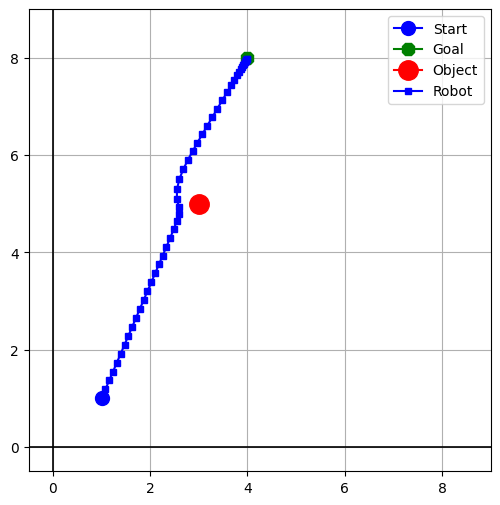

In [13]:
plt.figure(figsize=(6, 6))


plt.plot(initial[0], initial[1], 
         color='blue', marker='o', linestyle='-', markersize=10,
         label='Start')
plt.plot(goal[0], goal[1], 
         color='green', marker='8', linestyle='-', markersize=10,
         label='Goal')
plt.plot(obj[0], obj[1], 
         color='red', marker='o', linestyle='-', markersize=14 ,
         label='Object')

plt.plot(robot[0, :], robot[1, :], 
         color='blue', marker='s', linestyle='-', markersize=5,
         label='Robot')

# # Plot the 3 matching vectors
# plt.quiver(robot[0], robot[1], F_a[0], F_a[1], color='orange', label=r'$F_a$',
#            angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

# plt.quiver(robot[0], robot[1], F_r[0], F_r[1], color='purple', label=r'$F_r$',
#            angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

# plt.quiver(robot[0], robot[1], F[0], F[1], color='pink', label=r'$F_{net}$',
#            angles='xy', scale_units='xy', scale=1, width=0.005, headwidth=4.5, headlength=5)

plt.legend()

# Set your view limits so (0,0) is in the bottom-left and everything fits
plt.xlim(-0.5, 9)
plt.ylim(-0.5, 9)

# Formatting
plt.grid(True)
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.gca().set_aspect('equal')
plt.legend()

plt.show()